In [43]:
import pandas as pd

url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 607209
Columns: 61


In [72]:
# Save COVID-19 Dataset as CSV

df.to_csv("covid_data.csv", index=False)

print("covid_data.csv created successfully!")

covid_data.csv created successfully!


In [73]:
from google.colab import files

files.download("covid_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(607209, 61)

Column Names:
['country', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'excess_mortality', 'excess_mortality_cumulative', 'excess_mortality_cumulative_absolute', 'excess_mortality_cumulative_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'icu_patients', 'icu_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'stringency_index', 'reproduction_rate', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_v

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1964.452271,NaN,11.7,51.938343,0.35,NaN


In [45]:
print("Missing Values in Each Column:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Missing Values in Each Column:
human_development_index                    607209
weekly_icu_admissions                      596216
weekly_icu_admissions_per_million          596216
excess_mortality_cumulative_per_million    593412
excess_mortality                           593378
excess_mortality_cumulative                593378
excess_mortality_cumulative_absolute       593378
weekly_hosp_admissions_per_million         582712
weekly_hosp_admissions                     582712
icu_patients                               568093
icu_patients_per_million                   568093
hosp_patients_per_million                  566553
hosp_patients                              566553
total_boosters                             548425
total_boosters_per_hundred                 548425
dtype: int64


In [46]:
required_columns = [
    "country",
    "date",
    "total_cases",
    "new_cases",
    "total_deaths",
    "new_deaths"
]

print("Required Columns Check:\n")

for column in required_columns:
    if column in df.columns:
        print(f"✓ {column}")
    else:
        print(f"✗ {column} - Not Found")

Required Columns Check:

✓ country
✓ date
✓ total_cases
✓ new_cases
✓ total_deaths
✓ new_deaths


In [47]:
clean_df = df[
    [
        "country",
        "date",
        "total_cases",
        "new_cases",
        "total_deaths",
        "new_deaths"
    ]
].copy()

# Convert date column into datetime format
clean_df["date"] = pd.to_datetime(clean_df["date"])

# Convert numerical columns to numeric format
numeric_columns = [
    "total_cases",
    "new_cases",
    "total_deaths",
    "new_deaths"
]

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

# Remove rows where important data is missing
clean_df.dropna(
    subset=["country", "date", "total_cases", "total_deaths"],
    inplace=True
)

# Sort data by country and date
clean_df.sort_values(
    by=["country", "date"],
    inplace=True
)

clean_df.reset_index(drop=True, inplace=True)

print("Data cleaning completed successfully!")
print("Cleaned dataset shape:", clean_df.shape)
display(clean_df.head())

Data cleaning completed successfully!
Cleaned dataset shape: (594861, 6)


,country,date,total_cases,new_cases,total_deaths,new_deaths
0,Afghanistan,2020-01-04,0.0,0.0,0.0,0.0
1,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0
2,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0
3,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0
4,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0


In [48]:
print("Basic Dataset Information")
print("-" * 35)

print("Total Records:", len(clean_df))
print("Total Countries:", clean_df["country"].nunique())
print("Start Date:", clean_df["date"].min().date())
print("End Date:", clean_df["date"].max().date())

print("\nTop 10 Countries by Total Cases:")

country_cases = (
    clean_df.groupby("country")["total_cases"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

print(country_cases)

Basic Dataset Information
-----------------------------------
Total Records: 594861
Total Countries: 249
Start Date: 2020-01-04
End Date: 2026-07-19

Top 10 Countries by Total Cases:
country
World                                                  779178934.0
World excl. China                                      679797173.0
World excl. China and South Korea                      645225300.0
World excl. China, South Korea, Japan and Singapore    608415573.0
High-income countries                                  458049855.0
Asia                                                   302204311.0
Upper-middle-income countries                          257538779.0
Europe                                                 254960114.0
Asia excl. China                                       202822550.0
European Union (27)                                    186984090.0
Name: total_cases, dtype: float64


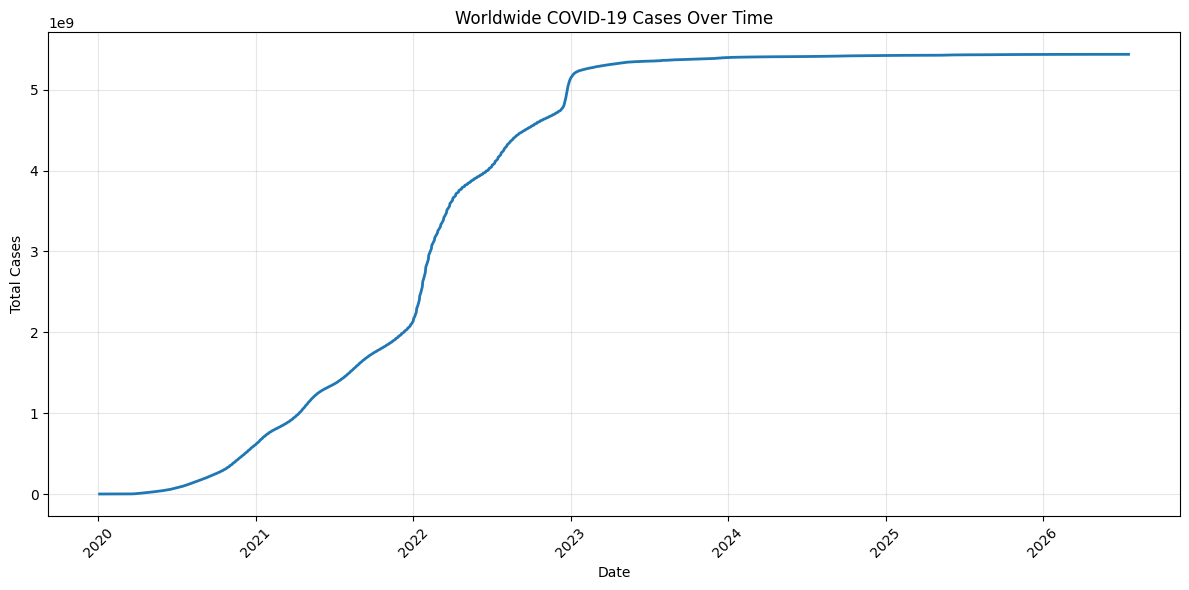

In [49]:
# Worldwide COVID-19 Cases Over Time

import matplotlib.pyplot as plt

worldwide_cases = (
    clean_df.groupby("date")["total_cases"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    worldwide_cases["date"],
    worldwide_cases["total_cases"],
    linewidth=2
)

plt.title("Worldwide COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

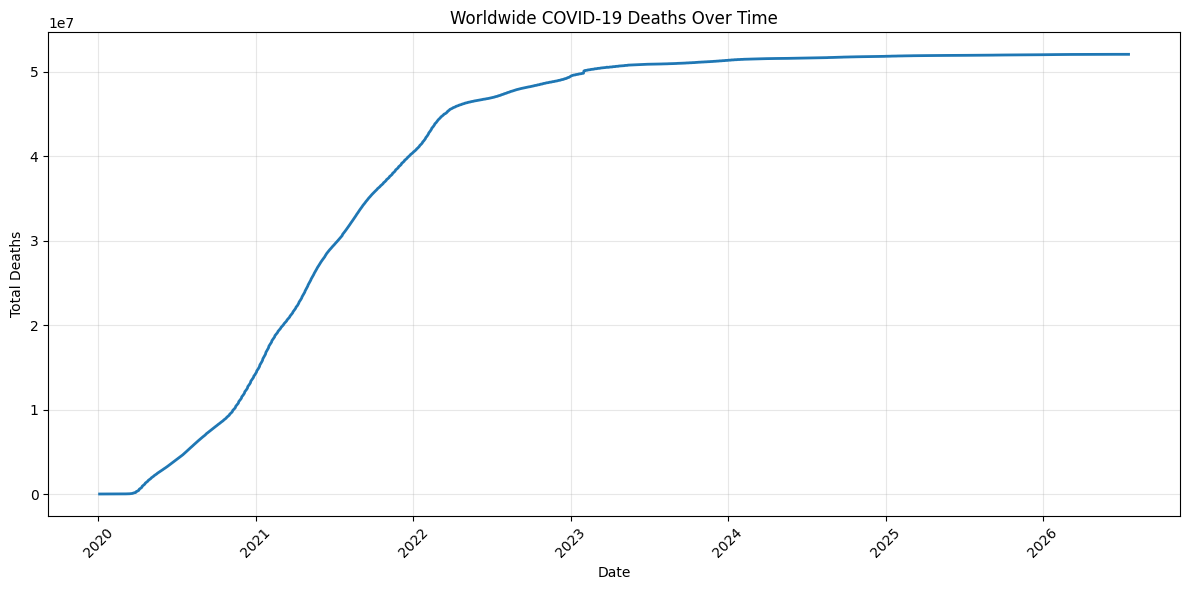

In [50]:
# Worldwide COVID-19 Deaths Over Time

worldwide_deaths = (
    clean_df.groupby("date")["total_deaths"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    worldwide_deaths["date"],
    worldwide_deaths["total_deaths"],
    linewidth=2
)

plt.title("Worldwide COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

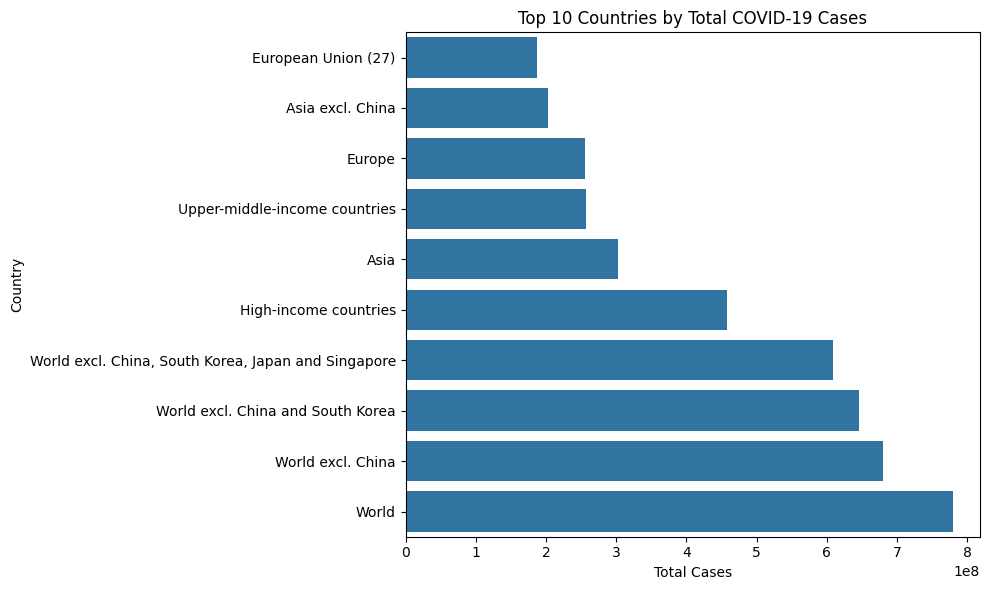

In [51]:
# Top 10 Countries by Total COVID-19 Cases

import matplotlib.pyplot as plt
import seaborn as sns

top_countries = (
    clean_df.groupby("country")["total_cases"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

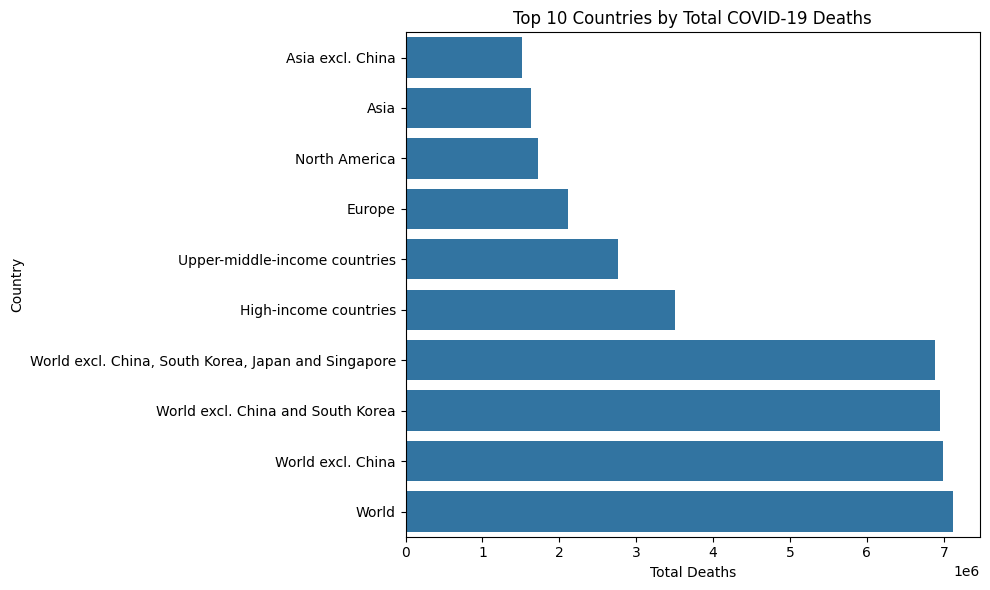

In [52]:
# Top 10 Countries by Total COVID-19 Deaths

import matplotlib.pyplot as plt
import seaborn as sns

top_death_countries = (
    clean_df.groupby("country")["total_deaths"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_death_countries.values,
    y=top_death_countries.index
)

plt.title("Top 10 Countries by Total COVID-19 Deaths")
plt.xlabel("Total Deaths")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

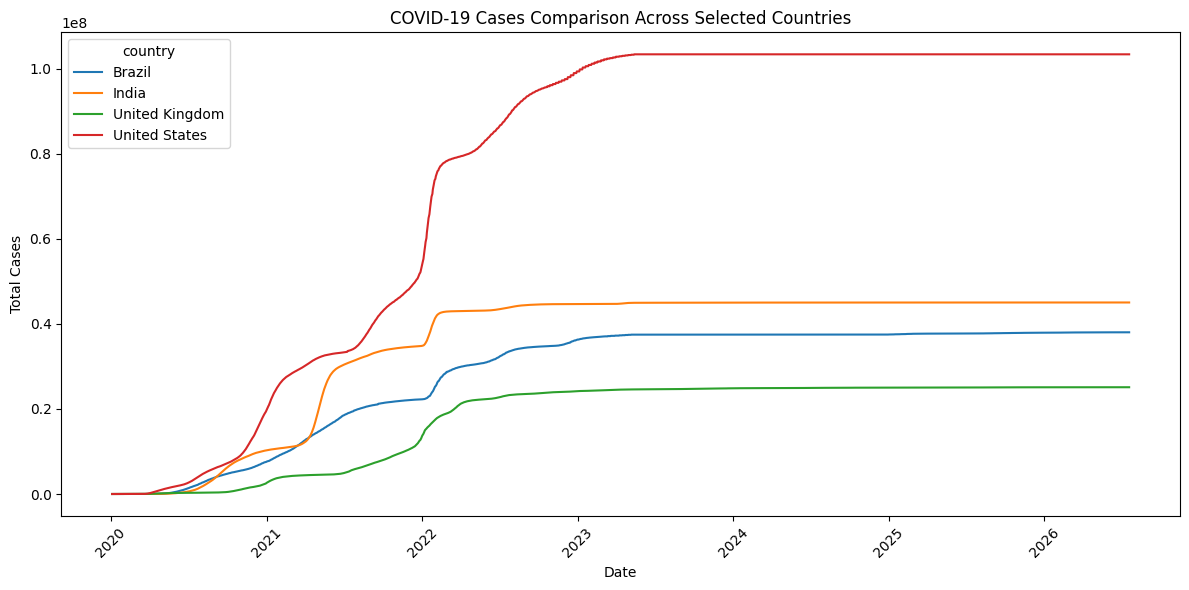

In [53]:
# COVID-19 Cases Comparison Across Selected Countries

selected_countries = ["India", "United States", "Brazil", "United Kingdom"]

country_data = clean_df[
    clean_df["country"].isin(selected_countries)
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=country_data,
    x="date",
    y="total_cases",
    hue="country"
)

plt.title("COVID-19 Cases Comparison Across Selected Countries")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

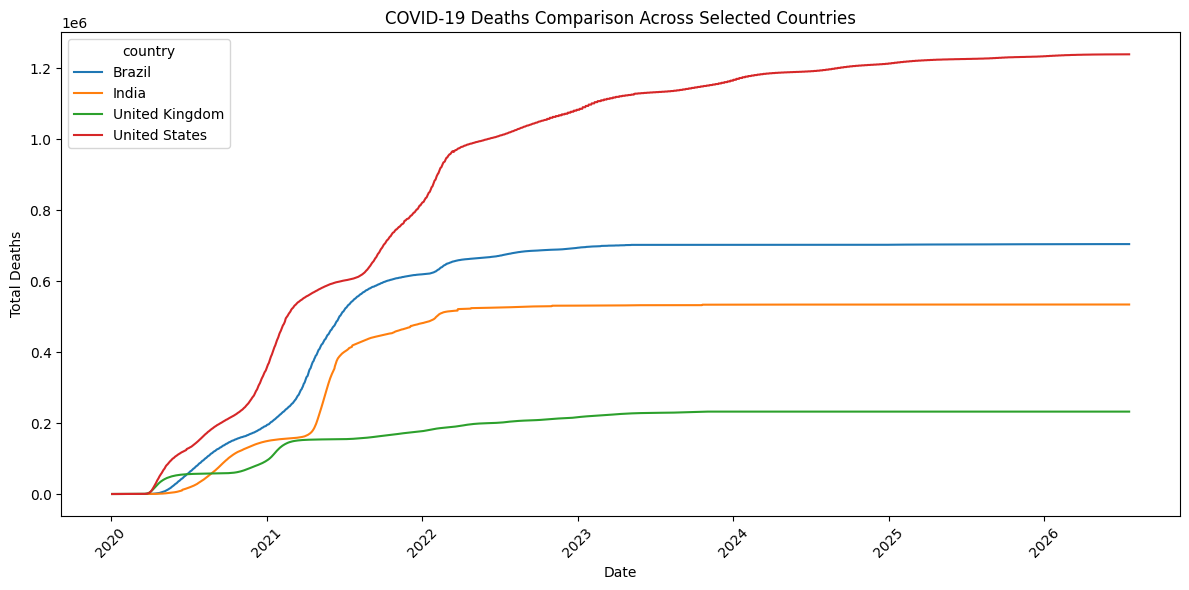

In [54]:
# COVID-19 Deaths Comparison Across Selected Countries

selected_countries = ["India", "United States", "Brazil", "United Kingdom"]

country_death_data = clean_df[
    clean_df["country"].isin(selected_countries)
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=country_death_data,
    x="date",
    y="total_deaths",
    hue="country"
)

plt.title("COVID-19 Deaths Comparison Across Selected Countries")
plt.xlabel("Date")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

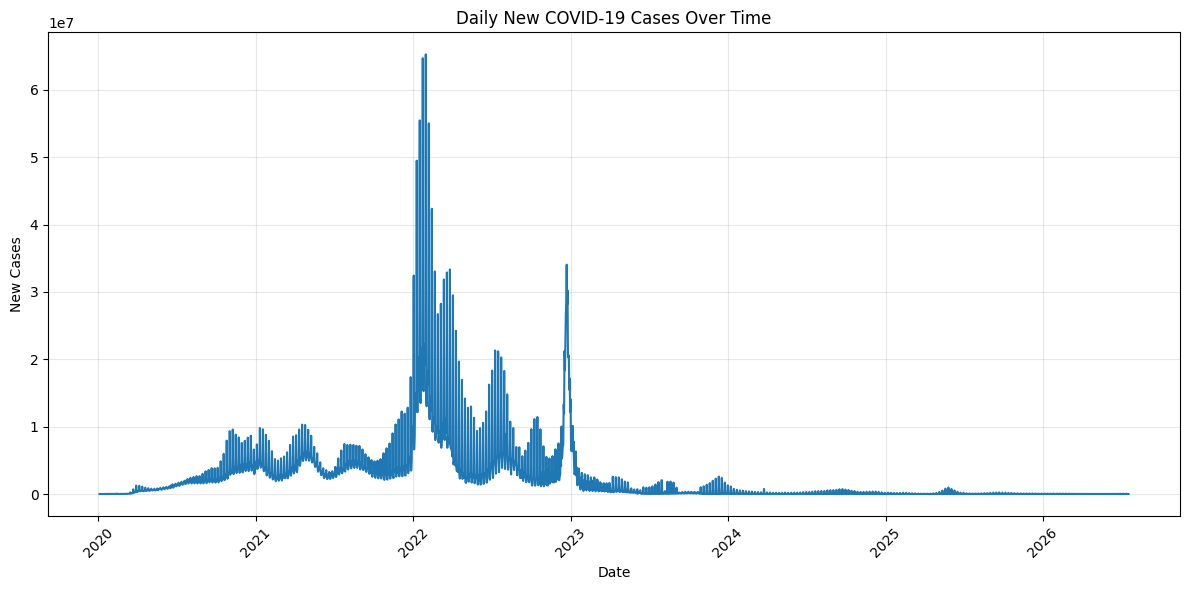

In [55]:
# Daily New COVID-19 Cases Over Time

daily_cases = (
    clean_df.groupby("date")["new_cases"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_cases["date"],
    daily_cases["new_cases"],
    linewidth=1.5
)

plt.title("Daily New COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

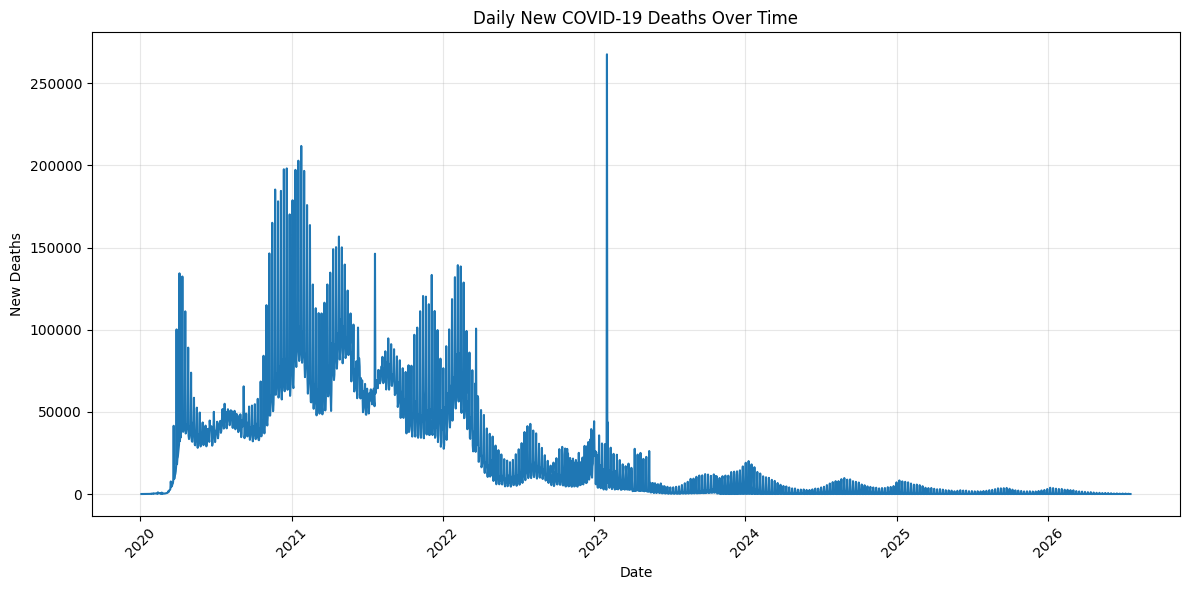

In [56]:
# Daily New COVID-19 Deaths Over Time

daily_deaths = (
    clean_df.groupby("date")["new_deaths"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_deaths["date"],
    daily_deaths["new_deaths"],
    linewidth=1.5
)

plt.title("Daily New COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("New Deaths")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

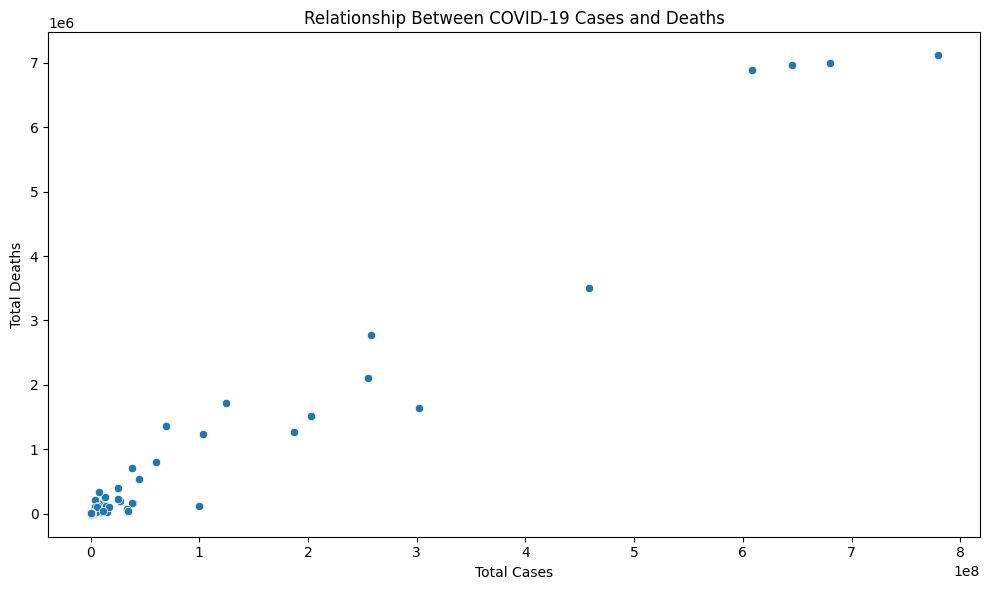

In [57]:
# Relationship Between COVID-19 Cases and Deaths

country_summary = (
    clean_df.groupby("country")[["total_cases", "total_deaths"]]
    .max()
    .dropna()
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=country_summary,
    x="total_cases",
    y="total_deaths"
)

plt.title("Relationship Between COVID-19 Cases and Deaths")
plt.xlabel("Total Cases")
plt.ylabel("Total Deaths")

plt.tight_layout()
plt.show()

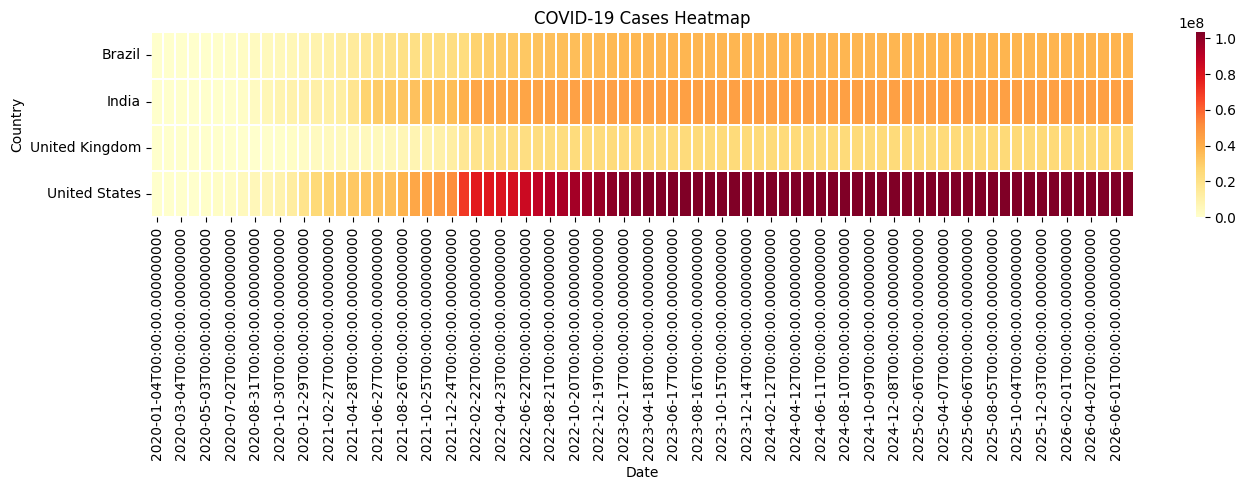

In [58]:
# COVID-19 Cases Heatmap for Selected Countries

selected_countries = ["India", "United States", "Brazil", "United Kingdom"]

heatmap_data = (
    clean_df[clean_df["country"].isin(selected_countries)]
    .pivot_table(
        index="country",
        columns="date",
        values="total_cases",
        aggfunc="max"
    )
)

# Reduce the number of dates for better visualization
heatmap_data = heatmap_data.iloc[:, ::30]

plt.figure(figsize=(14, 5))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.2
)

plt.title("COVID-19 Cases Heatmap")
plt.xlabel("Date")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [59]:
# Interactive COVID-19 Cases Visualization

import plotly.express as px

selected_countries = ["India", "United States", "Brazil", "United Kingdom"]

plotly_data = clean_df[
    clean_df["country"].isin(selected_countries)
]

fig = px.line(
    plotly_data,
    x="date",
    y="total_cases",
    color="country",
    title="Interactive COVID-19 Cases Comparison"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Total Cases"
)

fig.show()

In [60]:
# Country-wise COVID-19 Cases and Deaths Summary

country_summary = (
    clean_df[
        clean_df["country"].isin(
            ["India", "United States", "Brazil", "United Kingdom"]
        )
    ]
    .groupby("country")[["total_cases", "total_deaths"]]
    .max()
    .sort_values("total_cases", ascending=False)
)

print("Country-wise COVID-19 Summary:")
display(country_summary)

Country-wise COVID-19 Summary:


,total_cases,total_deaths
country,,
United States,103436829.0,1238678.0
India,45056221.0,533849.0
Brazil,38042729.0,704045.0
United Kingdom,25118508.0,232112.0


In [61]:
# Loading Historical COVID-19 Recovery Data

recovery_url = "https://raw.githubusercontent.com/imdevskp/covid_19_jhu_data_web_scrap_and_cleaning/master/time_series_covid19_recovered_global.csv"

recovery_df = pd.read_csv(recovery_url)

print("Recovery dataset loaded successfully!")
print("Rows:", recovery_df.shape[0])
print("Columns:", recovery_df.shape[1])

display(recovery_df.head())

Recovery dataset loaded successfully!
Rows: 253
Columns: 192


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,23273,23634,23741,23741,23924,24550,24602,24793,25180,25198
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2264,2311,2352,2397,2463,2523,2608,2637,2682,2745
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,15744,16051,16400,16646,16983,17369,17369,18076,18088,18837
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,803,803,803,803,803,803,803,803,803,803
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,210,221,221,221,221,236,241,242,242,242


In [62]:
# Inspecting Recovery Dataset

print("Recovery Dataset Shape:")
print(recovery_df.shape)

print("\nRecovery Dataset Columns:")
print(recovery_df.columns.tolist())

print("\nFirst 5 Rows:")
display(recovery_df.head())

Recovery Dataset Shape:
(253, 192)

Recovery Dataset Columns:
['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20', '2/8/20', '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20', '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20', '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20', '2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20', '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20', '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20', '3/16/20', '3/17/20', '3/18/20', '3/19/20', '3/20/20', '3/21/20', '3/22/20', '3/23/20', '3/24/20', '3/25/20', '3/26/20', '3/27/20', '3/28/20', '3/29/20', '3/30/20', '3/31/20', '4/1/20', '4/2/20', '4/3/20', '4/4/20', '4/5/20', '4/6/20', '4/7/20', '4/8/20', '4/9/20', '4/10/20', '4/11/20', '4/12/20', '4/13/20', 

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,7/18/20,7/19/20,7/20/20,7/21/20,7/22/20,7/23/20,7/24/20,7/25/20,7/26/20,7/27/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,23273,23634,23741,23741,23924,24550,24602,24793,25180,25198
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2264,2311,2352,2397,2463,2523,2608,2637,2682,2745
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,15744,16051,16400,16646,16983,17369,17369,18076,18088,18837
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,803,803,803,803,803,803,803,803,803,803
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,210,221,221,221,221,236,241,242,242,242


In [63]:
# Converting Recovery Data into Long Format

recovery_long = recovery_df.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    var_name="date",
    value_name="recovered"
)

# Convert date column
recovery_long["date"] = pd.to_datetime(
    recovery_long["date"],
    format="%m/%d/%y"
)

# Calculate total recovered cases by country and date
recovery_country = (
    recovery_long
    .groupby(["Country/Region", "date"])["recovered"]
    .sum()
    .reset_index()
)

print("Recovery data converted successfully!")
print("Rows:", recovery_country.shape[0])
print("Columns:", recovery_country.shape[1])

display(recovery_country.head())

Recovery data converted successfully!
Rows: 35344
Columns: 3


,Country/Region,date,recovered
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0


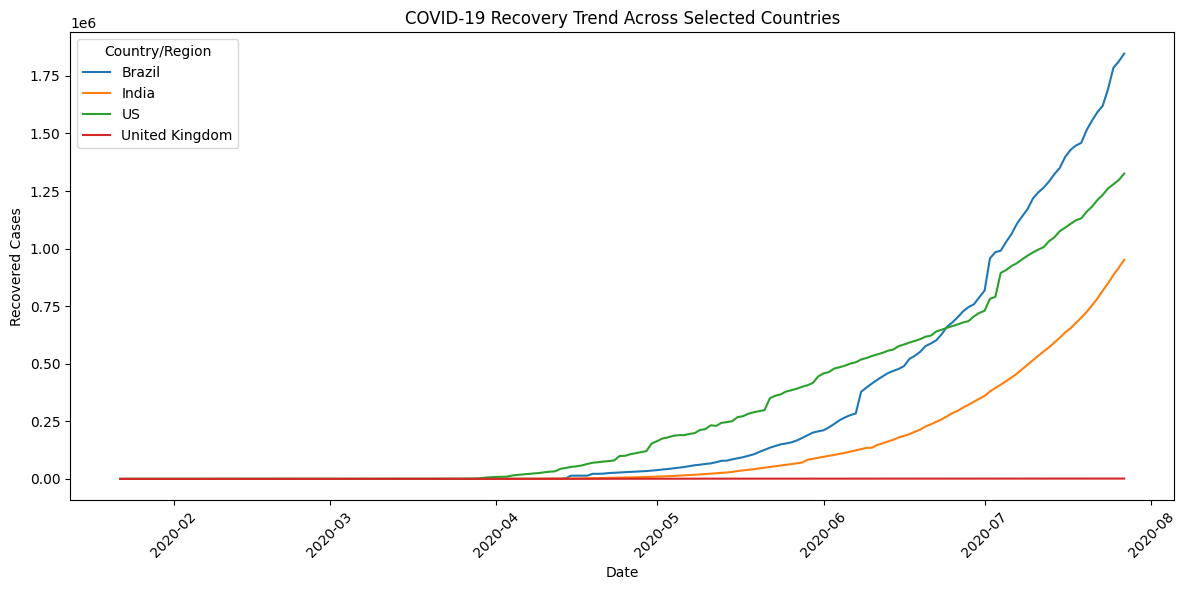

In [64]:
# COVID-19 Recovery Trend Across Selected Countries

selected_countries = ["India", "US", "Brazil", "United Kingdom"]

recovery_selected = recovery_country[
    recovery_country["Country/Region"].isin(selected_countries)
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=recovery_selected,
    x="date",
    y="recovered",
    hue="Country/Region"
)

plt.title("COVID-19 Recovery Trend Across Selected Countries")
plt.xlabel("Date")
plt.ylabel("Recovered Cases")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [65]:
# Loading Government Intervention Data

government_url = "https://ourworldindata.org/grapher/covid-containment-and-health-index.csv?v=1&csvType=full&useColumnShortNames=false"

government_df = pd.read_csv(
    government_url,
    storage_options={
        "User-Agent": "Our World in Data data fetch/1.0"
    }
)

print("Government intervention data loaded successfully!")
print("Rows:", government_df.shape[0])
print("Columns:", government_df.shape[1])

display(government_df.head())

Government intervention data loaded successfully!
Rows: 202760
Columns: 4


,Entity,Code,Day,COVID-19 Containment and Health Index
0,Afghanistan,AFG,2020-01-01,0.0
1,Afghanistan,AFG,2020-01-02,0.0
2,Afghanistan,AFG,2020-01-03,0.0
3,Afghanistan,AFG,2020-01-04,0.0
4,Afghanistan,AFG,2020-01-05,0.0


In [66]:
# Inspecting Government Intervention Data

print("Government Intervention Dataset Shape:")
print(government_df.shape)

print("\nColumn Names:")
print(government_df.columns.tolist())

print("\nFirst 5 Rows:")
display(government_df.head())

Government Intervention Dataset Shape:
(202760, 4)

Column Names:
['Entity', 'Code', 'Day', 'COVID-19 Containment and Health Index']

First 5 Rows:


,Entity,Code,Day,COVID-19 Containment and Health Index
0,Afghanistan,AFG,2020-01-01,0.0
1,Afghanistan,AFG,2020-01-02,0.0
2,Afghanistan,AFG,2020-01-03,0.0
3,Afghanistan,AFG,2020-01-04,0.0
4,Afghanistan,AFG,2020-01-05,0.0


In [67]:
# Checking Government Intervention Column Names

print("Government Intervention Columns:")

for column in government_df.columns:
    print(column)

Government Intervention Columns:
Entity
Code
Day
COVID-19 Containment and Health Index


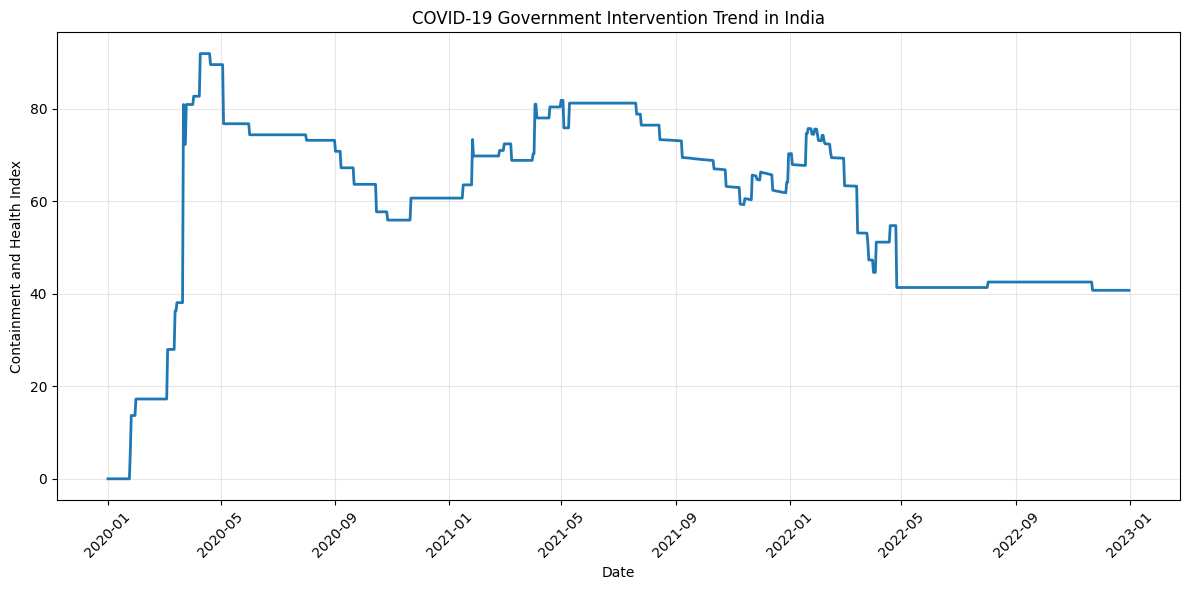

In [68]:
# Government Intervention Trend in India

india_government = government_df[
    government_df["Entity"] == "India"
].copy()

india_government["Day"] = pd.to_datetime(india_government["Day"])

plt.figure(figsize=(12, 6))

plt.plot(
    india_government["Day"],
    india_government["COVID-19 Containment and Health Index"],
    linewidth=2
)

plt.title("COVID-19 Government Intervention Trend in India")
plt.xlabel("Date")
plt.ylabel("Containment and Health Index")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

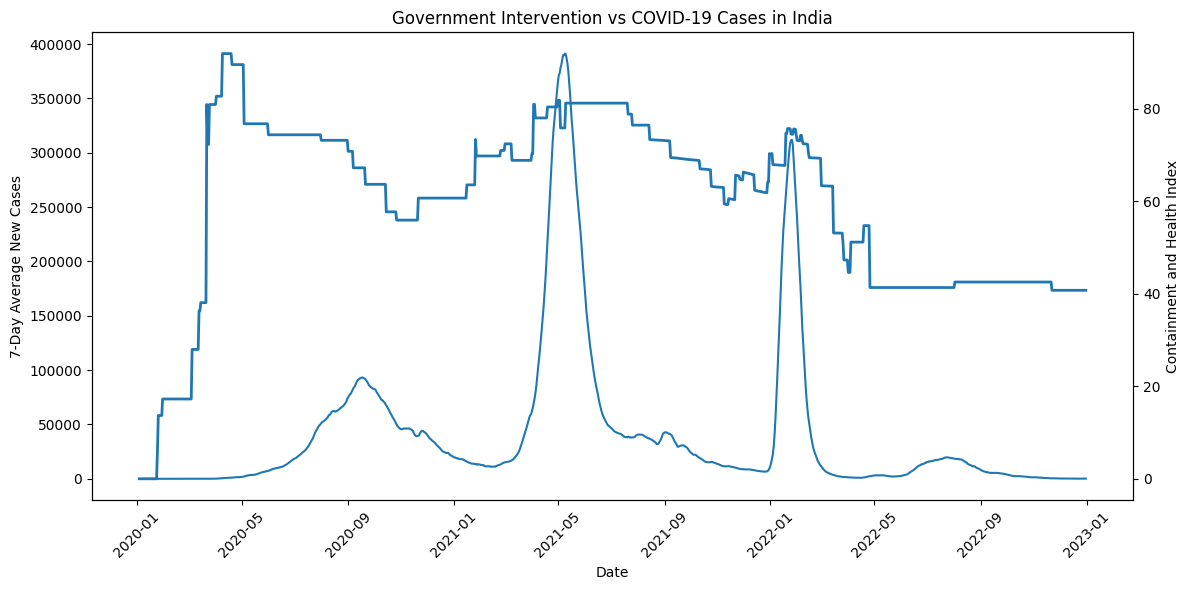

In [69]:
# Government Intervention vs New COVID-19 Cases in India

india_cases = clean_df[
    clean_df["country"] == "India"
][["date", "new_cases"]].copy()

india_cases = (
    india_cases
    .groupby("date")["new_cases"]
    .sum()
    .reset_index()
)

india_cases["new_cases"] = (
    india_cases["new_cases"]
    .rolling(7)
    .mean()
)

india_intervention = government_df[
    government_df["Entity"] == "India"
][[
    "Day",
    "COVID-19 Containment and Health Index"
]].copy()

india_intervention["Day"] = pd.to_datetime(
    india_intervention["Day"]
)

comparison_data = pd.merge(
    india_cases,
    india_intervention,
    left_on="date",
    right_on="Day",
    how="inner"
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    comparison_data["date"],
    comparison_data["new_cases"],
    linewidth=1.5
)

ax1.set_xlabel("Date")
ax1.set_ylabel("7-Day Average New Cases")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    comparison_data["date"],
    comparison_data["COVID-19 Containment and Health Index"],
    linewidth=2
)

ax2.set_ylabel("Containment and Health Index")

plt.title("Government Intervention vs COVID-19 Cases in India")

fig.tight_layout()
plt.show()

In [70]:
# Cases, Recoveries and Deaths Summary

selected_countries = [
    "India",
    "United States",
    "Brazil",
    "United Kingdom"
]

cases_deaths_summary = (
    clean_df[
        clean_df["country"].isin(selected_countries)
    ]
    .groupby("country")[["total_cases", "total_deaths"]]
    .max()
    .reset_index()
)

recovery_summary = (
    recovery_country[
        recovery_country["Country/Region"].isin(
            ["India", "US", "Brazil", "United Kingdom"]
        )
    ]
    .groupby("Country/Region")["recovered"]
    .max()
    .reset_index()
)

recovery_summary["Country/Region"] = recovery_summary[
    "Country/Region"
].replace({
    "US": "United States"
})

final_summary = pd.merge(
    cases_deaths_summary,
    recovery_summary,
    left_on="country",
    right_on="Country/Region",
    how="left"
)

final_summary.drop(
    columns=["Country/Region"],
    inplace=True
)

final_summary.rename(
    columns={
        "country": "Country",
        "total_cases": "Total Cases",
        "total_deaths": "Total Deaths",
        "recovered": "Recovered Cases"
    },
    inplace=True
)

print("COVID-19 Cases, Recoveries and Deaths Summary:")
display(final_summary)

COVID-19 Cases, Recoveries and Deaths Summary:


,Country,Total Cases,Total Deaths,Recovered Cases
0,Brazil,38042729.0,704045.0,1846641
1,India,45056221.0,533849.0,951166
2,United Kingdom,25118508.0,232112.0,1437
3,United States,103436829.0,1238678.0,1325804


In [71]:
# Final COVID-19 Analysis Findings

highest_cases = final_summary.loc[
    final_summary["Total Cases"].idxmax()
]

highest_deaths = final_summary.loc[
    final_summary["Total Deaths"].idxmax()
]

highest_recoveries = final_summary.loc[
    final_summary["Recovered Cases"].idxmax()
]

print("COVID-19 Analysis Findings")
print("-" * 35)

print(
    f"Highest Total Cases: "
    f"{highest_cases['Country']} "
    f"({highest_cases['Total Cases']:,.0f})"
)

print(
    f"Highest Total Deaths: "
    f"{highest_deaths['Country']} "
    f"({highest_deaths['Total Deaths']:,.0f})"
)

print(
    f"Highest Recovered Cases: "
    f"{highest_recoveries['Country']} "
    f"({highest_recoveries['Recovered Cases']:,.0f})"
)

print("\nGovernment intervention trends were compared")
print("with COVID-19 case trends for India.")

COVID-19 Analysis Findings
-----------------------------------
Highest Total Cases: United States (103,436,829)
Highest Total Deaths: United States (1,238,678)
Highest Recovered Cases: Brazil (1,846,641)

Government intervention trends were compared
with COVID-19 case trends for India.


## Conclusion

The COVID-19 Visualization Data Analysis project provided an overview of the spread of COVID-19 using cases, deaths, recoveries, and government intervention data.

The analysis showed how COVID-19 cases and deaths changed over time and how different countries experienced different levels of impact. Recovery data was also analyzed using historical data.

The government intervention analysis for India helped visualize changes in containment and health measures alongside COVID-19 case trends.

Overall, Pandas was used for data processing and analysis, Matplotlib and Seaborn were used for static visualizations, and Plotly was used to create interactive visualizations.